In [1]:
import numpy as np
import matplotlib.pyplot as plt

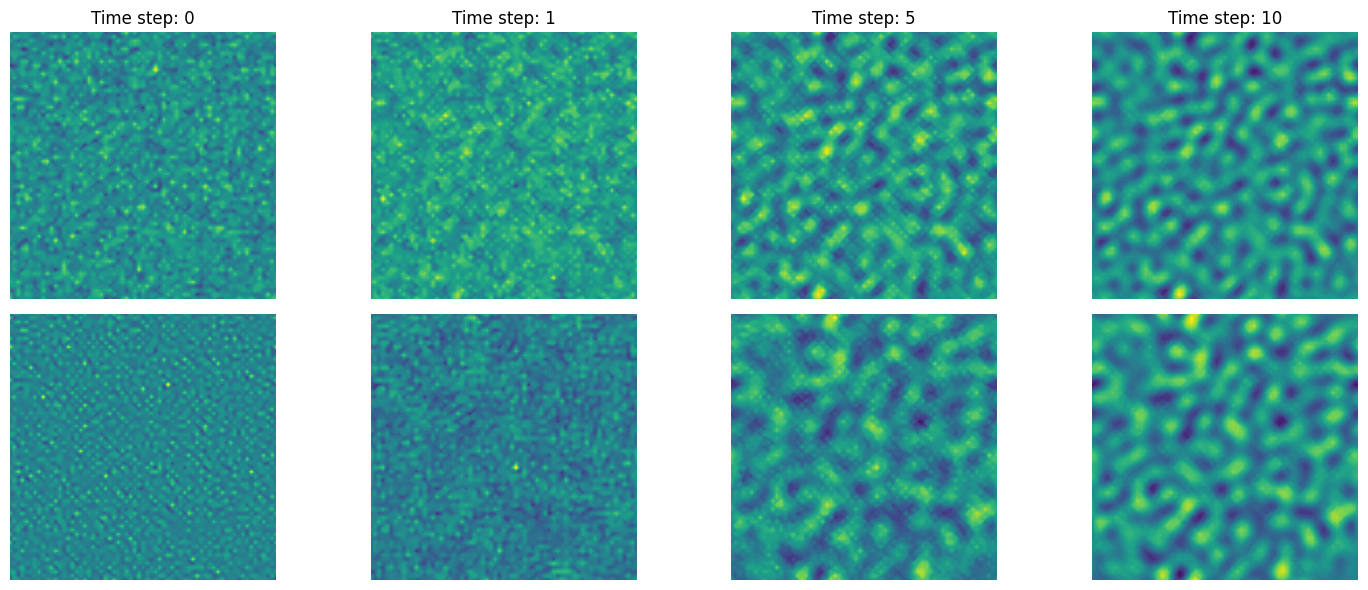

In [2]:
save_dir = "./data"
solutions = np.load(f"{save_dir}/train_valid/solutions_grid.npy")
mesh = np.load(f"{save_dir}/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
tics = [0, 1, 5, 10,]

fig, axes = plt.subplots(2, len(tics), figsize=(15, 6))
for i, tic in enumerate(tics):
    ax = axes[0, i]
    im = ax.contourf(meshx, meshy, solutions[0, tic, 0, ...],
                     levels=50, cmap='viridis')
    ax.set_title(f'Time step: {tic}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # fig.colorbar(im, ax=ax)
    ax.set_aspect('equal')
    ax.set_axis_off()

    ax = axes[1, i]
    im = ax.contourf(meshx, meshy, solutions[0, tic, 1, ...],
                     levels=50, cmap='viridis')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # fig.colorbar(im, ax=ax)
    ax.set_aspect('equal')
    ax.set_axis_off()
fig.tight_layout()

In [3]:
solutions[0, 1, 1, ...].min(), solutions[0, 1, 1, ...].max()

(np.float64(-0.13060315502474557), np.float64(0.19489914992505503))

In [4]:
solutions.shape

(20, 101, 2, 65, 65)

In [5]:
from configs.train_debug import Configs
configs = Configs()

def prepare_data(data_dir):

    mesh = np.load(f"{data_dir}/mesh_grid_coords.npy")
    mesh = np.transpose(mesh, (2, 0, 1))
    meshx = mesh[0, :, :]
    meshy = mesh[1, :, :]
    times = np.load(f"{data_dir}/times.npy")
    dt = times[1] - times[0]
    num_times = times.shape[0]
    solutions = np.load(f"{data_dir}/solutions_grid.npy", allow_pickle=True)
    num_ics = solutions.shape[0]
    Xs = np.zeros(
        ((num_times-1)*num_ics, 4, mesh.shape[1], mesh.shape[2])
    ) 
    Ys = np.zeros(
        ((num_times-1)*num_ics, 2, mesh.shape[1], mesh.shape[2])
    )

    for i in range(num_ics):
        Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # phi
        Xs[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, :-1, 1, :, :]  # c
        # mesh_x_repeated = np.repeat(mesh[:, :, 0][np.newaxis, :, :], num_times-1, axis=0)
        # Xs[i*(num_times-1):(i+1)*(num_times-1), 2, :, :] = mesh_x_repeated / configs.Lc  # x
        # mesh_y_repeated = np.repeat(mesh[:, :, 1][np.newaxis, :, :], num_times-1, axis=0)
        # Xs[i*(num_times-1):(i+1)*(num_times-1), 3, :, :] = mesh_y_repeated / configs.Lc # y

        Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # phi at next time step
        Ys[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, 1:, 1, :, :]  # c
    meshes_repeated = np.repeat(mesh[np.newaxis, :, :, :], Xs.shape[0], axis=0)
    Xs[:, 2, :, :] = meshes_repeated[:, 0, :, :] / configs.Lc  # x
    Xs[:, 3, :, :] = meshes_repeated[:, 1, :, :] / configs.Lc # y
    return Xs, Ys
Xs, Ys = prepare_data(f"{save_dir}/train_valid")
Xs_init_steps, Ys_init_steps = prepare_data(f"{save_dir}/train_init_steps")
Xs = np.concatenate([Xs, Xs_init_steps], axis=0)
Ys = np.concatenate([Ys, Ys_init_steps], axis=0)
Xs.shape, Ys.shape

((2200, 4, 65, 65), (2200, 2, 65, 65))

-0.22403847209404196 0.2557247127434544 -0.2127801266771015 0.17847345565382536 4.609299857665644e-06 0.3641898299987343
-0.1416072089767834 0.14183895507762662 -0.1525444601162283 0.1604109627618979 4.1201195127155144e-07 0.12515173352577705
-0.18424631147413562 0.2079937801443329 -0.20227362013099068 0.2364892652186376 6.7203489480527345e-06 0.07658725772107428


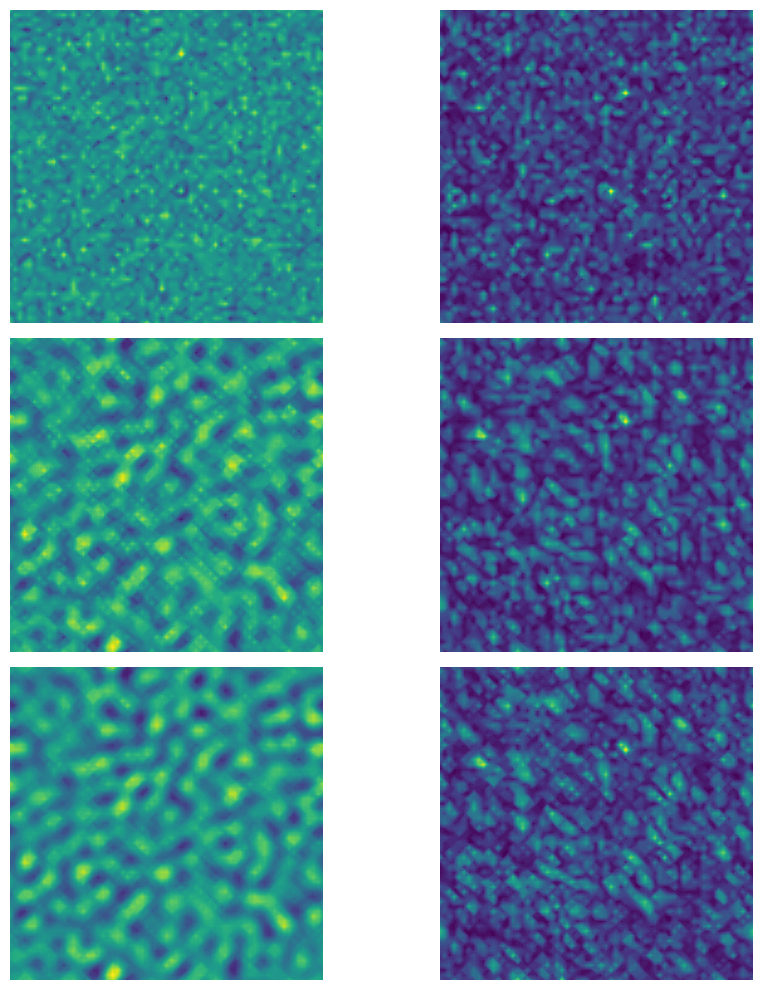

In [6]:
import matplotlib.pyplot as plt
ts = [0, 5, 9]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for idx, t in enumerate(ts):
    t += 0
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 2, :, :] * configs.Lc
    meshy = Xs[t, 3, :, :] * configs.Lc
    ax = axes[idx, 0]
    # im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")
    ax.contourf(meshx, meshy, x, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    # im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")
    ax.contourf(meshx, meshy, diff, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()
    print(x.min(), x.max(), y.min(), y.max(), diff.min(), diff.max())
fig.tight_layout()


[0.31166397 0.03933289 0.02599345 0.01974326 0.0159169  0.01327546
 0.0113103  0.00984945 0.00864158 0.00775087 0.00697731 0.00643565
 0.00598162 0.00571728 0.0055078  0.00546026 0.00543176 0.00547541
 0.00551995 0.00554435]


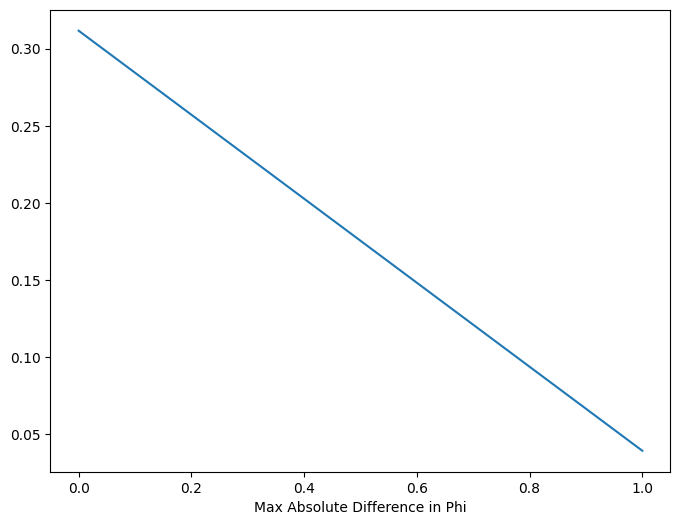

In [7]:
diffs = Xs[:, 1, ...] - Ys[:, 1, ...]
diffs = np.abs(diffs)

# diffs[:, 0].max(), diffs[:, 1].max(), diffs[:, 0].min(), diffs[:, 1].min()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.plot(diffs.mean(axis=(-1,-2))[:2])
ax.set_xlabel('Max Absolute Difference in Phi')
print(np.mean(diffs, axis=(-1,-2))[:20])

In [8]:
times = np.load(f"{save_dir}/train_valid/times.npy")
dt = times[1] - times[0]
dt

np.float64(5e-05)

In [9]:
np.savez(
    "./data/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)

In [10]:
Xs.shape, Ys.shape

((2200, 4, 65, 65), (2200, 2, 65, 65))